In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.signal import butter, filtfilt, resample
from sklearn.preprocessing import StandardScaler, LabelEncoder
import mne
from glob import glob

# Filter selection: 'data_curation' or 'notebook'
# 'data_curation': Uses filter from data_curation.py (lowcut=8, highcut=30, order=5)
# 'notebook': Uses original notebook filter (lowcut=4, highcut=40, order=5)
FILTER_TYPE = 'notebook'  # Change this to switch between filters

# Trial detection method: 'automatic' or 'trial_index'
# 'automatic': Uses phase sequence detection from data_curation.py (detects baseline->instruction->reach/stimulus)
# 'trial_index': Uses pre-existing trial_index column (original notebook method)
TRIAL_DETECTION_METHOD = 'trial_index'  # Change this to switch between detection methods

In [ ]:
# Load dataset
# data = pd.read_csv('data/shivansh_five_class_run_2.csv', header=None)
# print(data.head())

# Load and combine multiple files
# files = [
#     # 'data/EEG_bar_trials_20_classes_3_20251118_164048.csv',
#     # 'data/EEG_bar_trials_20_classes_3_20251118_174039.csv',
#     # 'data/EEG_bar_trials_20_classes_3_20251118_174039.csv',
#     'data/EEG_bar_trials_30_classes_3_20251118_161525.csv'
# ]

# data_list = [pd.read_csv(f) for f in files]
# data = pd.concat(data_list, ignore_index=True)
# print(f"Combined data shape: {data.shape}")

files = sorted(glob('data/Subject 1/2_class/EEG_bar_trials_*.csv'))
print(f"Found {len(files)} files:")
for f in files:
    print(f"  - {f}")

if len(files) == 0:
    print("WARNING: No files found! Check your data directory path.")
else:
    data_list = []
    max_trial_index = 0
    
    # Load files and make trial_index unique across files
    for f in files:
        df = pd.read_csv(f)
        if 'trial_index' in df.columns:
            # Offset trial_index to make it unique across files
            df['trial_index'] = df['trial_index'] + max_trial_index
            max_trial_index = df['trial_index'].max() + 1
        data_list.append(df)
    
    data = pd.concat(data_list, ignore_index=True)
    
    # Filter out class_label == 0 from all files
    initial_shape = data.shape
    data = data[data['class_label'] != 0]
    filtered_shape = data.shape
    print(f"Initial data shape: {initial_shape}")
    print(f"After filtering class_label == 0: {filtered_shape}")
    print(f"Removed {initial_shape[0] - filtered_shape[0]} rows with class_label == 0")
    
    print(f"Combined data shape: {data.shape}")
    print(f"Unique trials: {data['trial_index'].nunique()}")
    print(f"Unique class labels: {data['class_label'].unique()}")

Found 4 files:
  - data/2_class\EEG_bar_trials_20_classes_2_20251222_184334.csv
  - data/2_class\EEG_bar_trials_20_classes_2_20251222_185333.csv
  - data/2_class\EEG_bar_trials_30_classes_2_20251222_175547.csv
  - data/2_class\EEG_bar_trials_30_classes_2_20251222_181846.csv
Initial data shape: (454896, 22)
After filtering class_label == 0: (454876, 22)
Removed 20 rows with class_label == 0
Combined data shape: (454876, 22)
Unique trials: 200
Unique class labels: [2 1]


In [4]:
def ensure_fixed_length(arr, n_samples=2250, n_channels=8):
    """Ensure a 2D array has exactly n_samples rows and n_channels columns by truncating or padding with zeros.

    - If `arr` is empty, returns zeros of shape (n_samples, n_channels).
    - If `arr` has fewer/more columns than `n_channels`, columns are padded/truncated.
    - If `arr` has fewer rows than `n_samples`, rows are padded; if more, rows are truncated.
    """
    if arr is None or arr.size == 0:
        return np.zeros((n_samples, n_channels), dtype=float)

    rows, cols = arr.shape
    # fix columns
    if cols > n_channels:
        arr = arr[:, :n_channels]
    elif cols < n_channels:
        pad_cols = np.zeros((rows, n_channels - cols), dtype=arr.dtype)
        arr = np.hstack([arr, pad_cols])

    # fix rows
    if rows >= n_samples:
        return arr[:n_samples, :]
    else:
        pad = np.zeros((n_samples - rows, arr.shape[1]), dtype=arr.dtype)
        return np.vstack([arr, pad])


def extract_eeg_trials_automatic(data: pd.DataFrame, eeg_col_start=5, eeg_col_end=13):
    """
    Automatic trial detection from data_curation.py - detects trials by phase sequence.
    Adapted to work with notebook's data structure (uses 'class_label' instead of 'task',
    and handles 'stimulus' phase instead of 'reach').
    
    Parameters:
        data (pd.DataFrame): DataFrame with 'phase', 'class_label', and EEG columns
        eeg_col_start, eeg_col_end: Column indices for EEG channels
    
    Returns:
        trials (List[np.ndarray]): List of EEG data arrays (shape: [time_steps, 8])
        labels (List): Corresponding class label for each trial
        splits (List): Corresponding split label for each trial (if available)
    """
    # Get EEG column names
    eeg_cols = data.columns[eeg_col_start:eeg_col_end]
    
    # Detect phase or class_label changes
    changes = (data["phase"] != data["phase"].shift()) | (
        data["class_label"] != data["class_label"].shift()
    )
    changed_rows = data[changes]
    
    trials_raw = []
    current_label = None
    current_phases = []
    start_idx = None
    # Expected phases: baseline -> instruction -> stimulus (or baseline -> stimulus if no instruction)
    # Try both sequences
    expected_phases_1 = ["baseline", "instruction", "stimulus"]
    expected_phases_2 = ["baseline", "stimulus"]
    change_indices = changed_rows.index.tolist()
    
    for i, idx in enumerate(change_indices):
        row = changed_rows.loc[idx]
        label = row["class_label"]
        phase = row["phase"]
        
        if current_label != label:
            current_label = label
            current_phases = []
            start_idx = None
        
        # Try full sequence first, then short sequence
        expected_phases = expected_phases_1 if "instruction" in data["phase"].values else expected_phases_2
        
        if len(current_phases) < len(expected_phases) and phase == expected_phases[len(current_phases)]:
            current_phases.append(phase)
            if len(current_phases) == 1:
                start_idx = idx
            
            if current_phases == expected_phases:
                end_idx = (
                    change_indices[i + 1] if i + 1 < len(change_indices) else len(data)
                )
                trial_df = data.loc[start_idx : end_idx - 1]
                trials_raw.append(trial_df)
                current_label = None
                current_phases = []
                start_idx = None
    
    # Extract EEG and labels
    trials = []
    labels = []
    splits = []
    for trial in trials_raw:
        eeg_data = trial.loc[:, eeg_cols].values
        task_label = trial["class_label"].iloc[0]
        split_label = trial["split"].iloc[0] if "split" in trial.columns else None
        trials.append(eeg_data)
        labels.append(task_label)
        splits.append(split_label)
    
    print(f"✅ Extracted {len(trials)} trials with labels (automatic detection).")
    return trials, labels, splits


def trails_by_time(data, fs=250, eeg_col_start=5, eeg_col_end=13, n_samples=1000, 
                   baseline_sec=3, apply_baseline_norm=True):
    """Build trials with fixed shape (n_samples, n_channels) for the MI (stimulus) phase.
    Optionally applies baseline normalization using baseline phase data.
    
    Args:
        data: DataFrame with trial_index, phase, class_label, split columns
        fs: Sampling frequency (Hz)
        eeg_col_start, eeg_col_end: Column indices for EEG channels
        n_samples: Target number of samples for MI window (e.g., 1000 for 4 sec at 250 Hz)
        baseline_sec: Duration of baseline in seconds (default 3 sec)
        apply_baseline_norm: If True, normalize MI by baseline mean/std per trial
    
    Returns: 
        trials (N_trials, n_samples, n_channels), trial_labels (N_trials,), trial_splits (N_trials,)
    """
    trials = []
    trial_labels = []
    trial_splits = []
    trial_indices = []  # Store original trial_index for baseline matching
    unique_trials = data['trial_index'].unique()
    print(f'Found {len(unique_trials)} unique trials.')

    # determine EEG columns (keep iloc behavior: columns 5:13 -> typically 8 channels)
    eeg_cols = data.columns[eeg_col_start:eeg_col_end]
    n_channels = len(eeg_cols)
    baseline_samples = int(baseline_sec * fs)  # e.g., 3 sec * 250 Hz = 750 samples

    for trial in unique_trials:
        if trial != 0:
            trial_data = data[data['trial_index'] == trial]
            label = trial_data['class_label'].values[0] if 'class_label' in trial_data.columns else None
            split = trial_data['split'].values[0] if 'split' in trial_data.columns else None

            # Extract baseline data (3 seconds)
            trial_baseline = trial_data[trial_data['phase'] == 'baseline']
            baseline_matrix = trial_baseline.loc[:, eeg_cols].values if len(trial_baseline) > 0 else np.zeros((0, n_channels))
            
            # Extract MI (stimulus) data (4 seconds)
            trial_MI = trial_data[trial_data['phase'] == 'stimulus']
            eeg_matrix = trial_MI.loc[:, eeg_cols].values if len(trial_MI) > 0 else np.zeros((0, n_channels))

            # Ensure baseline has at least baseline_samples (take first baseline_samples)
            if len(baseline_matrix) > baseline_samples:
                baseline_matrix = baseline_matrix[:baseline_samples]
            elif len(baseline_matrix) == 0:
                # No baseline data - use zeros (will result in no normalization)
                baseline_matrix = np.zeros((baseline_samples, n_channels))

            # Compute baseline statistics per channel
            if apply_baseline_norm and len(baseline_matrix) > 0:
                baseline_mean = np.mean(baseline_matrix, axis=0, keepdims=True)  # (1, n_channels)
                baseline_std = np.std(baseline_matrix, axis=0, keepdims=True) + 1e-8  # (1, n_channels), add epsilon to avoid division by zero
                
                # Normalize MI data by baseline: (MI - baseline_mean) / baseline_std
                if len(eeg_matrix) > 0:
                    eeg_matrix = (eeg_matrix - baseline_mean) / baseline_std
            else:
                # No normalization applied
                pass

            # ensure exactly n_samples rows and n_channels columns (truncate or pad)
            fixed = ensure_fixed_length(eeg_matrix, n_samples=n_samples, n_channels=n_channels)

            trials.append(fixed)
            trial_labels.append(label)
            trial_splits.append(split)
            trial_indices.append(trial)  # Store trial_index for baseline matching

    trials = np.array(trials)
    trial_labels = np.array(trial_labels)
    trial_splits = np.array(trial_splits)
    trial_indices = np.array(trial_indices)  # Store trial_index for baseline matching

    print(f'Built {len(trials)} trials -> each trial shape: {trials.shape[1:]}')
    if apply_baseline_norm:
        print(f'✅ Applied baseline normalization: (MI - baseline_mean) / baseline_std per trial')
    # return trials as (N, n_samples, n_channels), trial_labels, trial_splits, trial_indices
    return trials, trial_labels, trial_splits, trial_indices

# Run trial detection based on selected method
if TRIAL_DETECTION_METHOD == 'automatic':
    print(f"Using automatic trial detection (data_curation.py method)...")
    # Extract trials using automatic detection
    trials_list, trial_labels_list, trial_splits_list = extract_eeg_trials_automatic(data)
    
    # Convert to numpy arrays and extract only stimulus phase (matching data_curation.py behavior)
    # In data_curation.py, process_data() removes first 3 seconds (baseline+instruction) 
    # and keeps only the "reach" phase. Here we'll extract stimulus phase directly.
    trials_processed = []
    trial_labels_processed = []
    trial_splits_processed = []
    trial_indices_processed = []
    
    for i, (trial_data, label, split) in enumerate(zip(trials_list, trial_labels_list, trial_splits_list)):
        # Get the stimulus phase portion (last part of trial, similar to data_curation.py removing first 3 sec)
        # Assuming trial contains: baseline -> instruction -> stimulus
        # We want to extract stimulus portion (last ~4 seconds = 1000 samples at 250 Hz)
        # If trial is shorter, take what's available
        trial_array = trial_data
        # Take last 1000 samples (4 seconds) or all if shorter
        if len(trial_array) >= 1000:
            stimulus_data = trial_array[-1000:, :]  # Last 4 seconds
        else:
            stimulus_data = trial_array  # Use all if shorter
        
        trials_processed.append(stimulus_data)
        trial_labels_processed.append(label)
        trial_splits_processed.append(split)
        trial_indices_processed.append(i)
    
    # Convert to arrays
    trials = np.array([ensure_fixed_length(t, n_samples=1000, n_channels=8) for t in trials_processed])
    trial_labels = np.array(trial_labels_processed)
    trial_splits = np.array(trial_splits_processed) if trial_splits_processed[0] is not None else None
    trial_indices = np.array(trial_indices_processed)
    
    print(f"Built {len(trials)} trials -> each trial shape: {trials.shape[1:]}")
else:
    print(f"Using trial_index-based detection (original notebook method)...")
    # Run and build trials with baseline normalization
    # Your setup: 3 sec baseline, 4 sec MI (at 250 Hz: 750 baseline samples, 1000 MI samples)
    trials, trial_labels, trial_splits, trial_indices = trails_by_time(
        data, 
        n_samples=1000,  # 4 seconds of MI at 250 Hz
        baseline_sec=3,  # 3 seconds of baseline
        apply_baseline_norm=False  # We'll apply baseline normalization after filtering (Cell 13)
    )


Using trial_index-based detection (original notebook method)...
Found 200 unique trials.
Built 200 trials -> each trial shape: (1000, 8)


In [5]:
# %%
print(f"Total trials: {len(trials)}")
print(f"Class distribution across all trials:")
unique, counts = np.unique(trial_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} trials")

Total trials: 200
Class distribution across all trials:
  Class 1: 100 trials
  Class 2: 100 trials


In [6]:
# Create MI / baseline views (kept for reference)
MI = data[data['phase'] == 'stimulus']
baseline = data[data['phase'] == 'baseline']
print(f'MI Readings shape (rows in raw data): {MI.shape}')
print(f'Baseline Readings shape: {baseline.shape}')

# Show shapes of the built trials
print(f'Number of trials built: {len(trials)}')
if len(trials) > 0:
    print(f'Each trial shape (n_samples, n_channels): {trials.shape[1:]}')

# Convert per-trial data into a stacked continuous array so downstream cells that expect
# `readings`/`labels`/`split` still work without many changes.
# - readings: shape (n_trials * n_samples, n_channels)
# - labels:   repeated trial label per sample -> shape (n_trials * n_samples,)
# - split:    repeated trial split per sample
if len(trials) > 0:
    n_samples = trials.shape[1]
    n_channels = trials.shape[2]
    readings = trials.reshape(-1, n_channels)  # stack trials into continuous samples
    labels = np.repeat(trial_labels, n_samples)
    split = np.repeat(trial_splits, n_samples)

    print(f'Stacked readings shape: {readings.shape}')
    print(f'Stacked labels shape: {labels.shape}')
    print(f'Unique class labels (trials): {np.unique(trial_labels)}')
else:
    print('No trials were built; `readings` will fall back to using raw MI rows')

# If you want to continue using original MI-based readings instead, comment out the stacking above
# and uncomment the following two lines to use the row-wise MI values (not trimmed per-trial):
# readings = MI.iloc[:, 5:13].values
# labels = MI['class_label'].values


MI Readings shape (rows in raw data): (201705, 22)
Baseline Readings shape: (151628, 22)
Number of trials built: 200
Each trial shape (n_samples, n_channels): (1000, 8)
Stacked readings shape: (200000, 8)
Stacked labels shape: (200000,)
Unique class labels (trials): [1 2]


In [ ]:
# Create a trial-level train/test split if the CSV no longer provides one
trial_ids = np.asarray(trial_indices)
trial_labels_array = np.asarray(trial_labels)

if "trial_splits" not in globals() or trial_splits is None or not np.isin(trial_splits, ["train", "test"]).any():
    train_trial_ids, test_trial_ids = train_test_split(
        trial_ids,
        test_size=0.2,
        random_state=42,
        stratify=trial_labels_array,
    )
    trial_splits = np.where(np.isin(trial_ids, train_trial_ids), "train", "test")
    print("Created trial_splits in the notebook (80/20 stratified split).")
else:
    print("Using existing trial_splits from data.")

print(f"Train trials: {np.sum(trial_splits == 'train')}")
print(f"Test trials : {np.sum(trial_splits == 'test')}")

class_split_counts = (
    pd.DataFrame({"class_label": trial_labels_array, "split": trial_splits})
    .groupby(["class_label", "split"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["train", "test"], fill_value=0)
    .sort_index()
 )

print("\nPer-class trial counts (stratified split check):")
print(class_split_counts)

In [7]:
# %%
# DEPRECATED: This cell has been replaced by Cell 6 (trial-level balancing)
# The old approach caused label misalignment. Use Cell 6 instead.
#
# %%
# Balance data per class to use all files equally
# from collections import Counter

# train_idx = np.where(split == 'train')[0]
# test_idx  = np.where(split == 'test')[0]

# eeg_train = readings[train_idx]
# lbl_train = labels[train_idx]

# eeg_test = readings[test_idx]
# lbl_test = labels[test_idx]

# print("\n=== BEFORE balancing ===")
# print(f"Train samples: {eeg_train.shape[0]}")
# print(f"Train label distribution: {np.unique(lbl_train, return_counts=True)}")
# print(f"Test samples: {eeg_test.shape[0]}")
# print(f"Test label distribution: {np.unique(lbl_test, return_counts=True)}")

# Find minimum per class
# train_counts = Counter(lbl_train)
# test_counts = Counter(lbl_test)

# min_train_per_class = min(train_counts.values())
# min_test_per_class = min(test_counts.values())

# print(f"\nMinimum samples per class in train: {min_train_per_class}")
# print(f"Minimum samples per class in test: {min_test_per_class}")

# Balance function
# def balance_data(eeg_data, labels_data, min_samples_per_class):
#     balanced_eeg = []
#     balanced_labels = []
    
#     unique_classes = np.unique(labels_data)
#     for cls in unique_classes:
#         cls_idx = np.where(labels_data == cls)[0]
#         selected_idx = np.random.choice(cls_idx, size=min_samples_per_class, replace=False)
#         balanced_eeg.append(eeg_data[selected_idx])
#         balanced_labels.append(labels_data[selected_idx])
    
#     return np.vstack(balanced_eeg), np.concatenate(balanced_labels)

# Apply balancing
# eeg_train = balance_data(eeg_train, lbl_train, min_train_per_class)[0]
# lbl_train = balance_data(readings[train_idx], labels[train_idx], min_train_per_class)[1]

# eeg_test = balance_data(eeg_test, lbl_test, min_test_per_class)[0]
# lbl_test = balance_data(readings[test_idx], labels[test_idx], min_test_per_class)[1]

# print("\n=== AFTER balancing ===")
# print(f"Train samples: {eeg_train.shape[0]}")
# print(f"Train label distribution: {np.unique(lbl_train, return_counts=True)}")
# print(f"Test samples: {eeg_test.shape[0]}")
# print(f"Test label distribution: {np.unique(lbl_test, return_counts=True)}")

In [ ]:
# %%
# NEW: operate on whole trials to avoid label leakage and misaligned windows
from collections import Counter

# Ensure trial_splits exists and is usable even if this cell runs before split helper cells
trial_ids = np.asarray(trial_indices)
trial_labels_array = np.asarray(trial_labels)
valid_split_present = (
    "trial_splits" in globals()
    and trial_splits is not None
    and np.isin(trial_splits, ["train", "test"]).any()
    and np.sum(np.asarray(trial_splits) == "train") > 0
    and np.sum(np.asarray(trial_splits) == "test") > 0
)

if not valid_split_present:
    try:
        train_trial_ids, test_trial_ids = train_test_split(
            trial_ids,
            test_size=0.2,
            random_state=42,
            stratify=trial_labels_array,
        )
        split_mode = "stratified"
    except ValueError as e:
        print(f"Stratified split fallback due to: {e}")
        train_trial_ids, test_trial_ids = train_test_split(
            trial_ids,
            test_size=0.2,
            random_state=42,
        )
        split_mode = "random"

    trial_splits = np.where(np.isin(trial_ids, train_trial_ids), "train", "test")
    print(f"Created trial_splits in this cell ({split_mode}, 80/20).")

train_mask = trial_splits == 'train'
test_mask = trial_splits == 'test'

eeg_train_trials = trials[train_mask]
lbl_train_trials = trial_labels[train_mask]
trial_indices_train = trial_indices[train_mask]  # Store for baseline matching

eeg_test_trials = trials[test_mask]
lbl_test_trials = trial_labels[test_mask]
trial_indices_test = trial_indices[test_mask]  # Store for baseline matching

print("\n=== Trial-level split ===")
print(f"Train trials: {eeg_train_trials.shape[0]} | distribution: {np.unique(lbl_train_trials, return_counts=True)}")
print(f"Test trials : {eeg_test_trials.shape[0]} | distribution: {np.unique(lbl_test_trials, return_counts=True)}")

if eeg_train_trials.shape[0] == 0 or eeg_test_trials.shape[0] == 0:
    raise ValueError(
        "Train/test split produced an empty set. Check trial_labels distribution and split logic."
    )


def balance_trials(eeg_trials, label_trials):
    counts = Counter(label_trials)
    min_trials = min(counts.values())
    balanced_trials = []
    balanced_labels = []
    for cls in sorted(counts.keys()):
        cls_idx = np.where(label_trials == cls)[0]
        selected = np.random.choice(cls_idx, size=min_trials, replace=False)
        balanced_trials.append(eeg_trials[selected])
        balanced_labels.append(label_trials[selected])
    return np.vstack(balanced_trials), np.concatenate(balanced_labels)


# Balance trials and keep track of trial indices
def balance_trials_with_indices(eeg_trials, label_trials, trial_idx_array):
    counts = Counter(label_trials)
    min_trials = min(counts.values())
    balanced_trials = []
    balanced_labels = []
    balanced_indices = []
    for cls in sorted(counts.keys()):
        cls_idx = np.where(label_trials == cls)[0]
        selected = np.random.choice(cls_idx, size=min_trials, replace=False)
        balanced_trials.append(eeg_trials[selected])
        balanced_labels.append(label_trials[selected])
        balanced_indices.append(trial_idx_array[selected])
    return np.vstack(balanced_trials), np.concatenate(balanced_labels), np.concatenate(balanced_indices)

eeg_train_trials, lbl_train_trials, trial_indices_train = balance_trials_with_indices(
    eeg_train_trials, lbl_train_trials, trial_indices_train
)

print("\n=== After balancing train trials ===")
print(f"Train trials: {eeg_train_trials.shape[0]} | distribution: {np.unique(lbl_train_trials, return_counts=True)}")
print(f"Test trials  : {eeg_test_trials.shape[0]} | distribution (kept as-is): {np.unique(lbl_test_trials, return_counts=True)}")




=== Trial-level split ===
Train trials: 164 | distribution: (array([1, 2]), array([82, 82]))
Test trials : 36 | distribution: (array([1, 2]), array([18, 18]))

=== After balancing train trials ===
Train trials: 164 | distribution: (array([1, 2]), array([82, 82]))
Test trials  : 36 | distribution (kept as-is): (array([1, 2]), array([18, 18]))


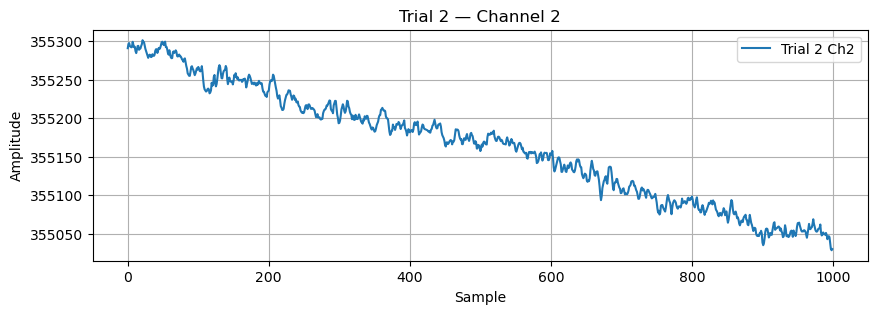

c:\Anaconda\Lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 1024 is greater than input length  = 1000, using nperseg = 1000
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


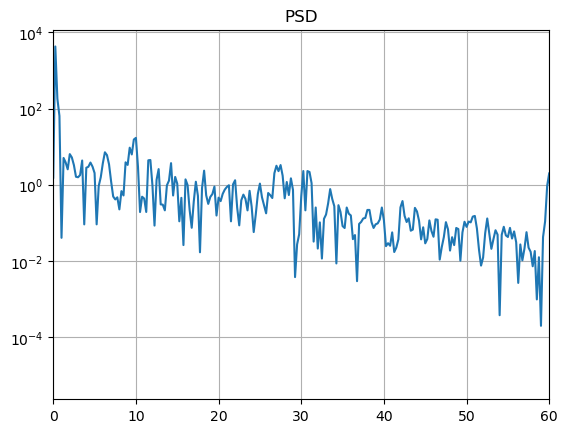

In [9]:
import matplotlib.pyplot as plt
# Show one trial (trial index 0), channel 0
trial_idx = 2
ch = 2
plt.figure(figsize=(10,3))
plt.plot(trials[trial_idx, :, ch], label=f'Trial {trial_idx} Ch{ch}')
plt.title(f'Trial {trial_idx} — Channel {ch}')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

# PSD check for same trial/channel
from scipy.signal import welch
f, Pxx = welch(trials[trial_idx, :, ch], fs=250, nperseg=1024)
plt.semilogy(f, Pxx); plt.xlim(0,60); plt.title('PSD'); plt.grid(True); plt.show()

In [10]:
# readings = MI.iloc[:, 5:13].values
# labels = MI['class_label'].values
# split = MI['split'].values
# print(f'Readings shape: {readings.shape}, Labels shape: {labels}')
# left_hand_count = np.sum(labels == 'left_arm')
# upper_data = MI.iloc[labels == 1]
# upper_data_readings = upper_data.iloc[:, 5:13].values

# middle_data = MI.iloc[labels == 2]
# middle_data_readings = middle_data.iloc[:, 5:13].values

# lower_data = MI.iloc[labels == 3]
# lower_data_readings = lower_data.iloc[:, 5:13].values

# print(f'Number of upper data labels: {upper_data_readings}')
# print(f'Number of middle data labels: {middle_data_readings}')
# print(f'Number of lower data labels: {lower_data_readings}')



# print(labels)
# la = []
# ra = []
# rl = []
# ll = []
# s = []
# # assume you already did:
# readings = MI.iloc[:, 5:13].values   # shape (n_samples, n_channels)
# labels   = MI['class_label'].values      # shape (n_samples,)

# s = []
# la = []
# ra = []
# rl = []
# ll = []

# n = len(labels)
# for i in range(n):
#     lbl = labels[i]                      # <- single string label for row i
#     row = readings[i, :]                 # <- 1D array for that sample's 8 channels
#     if lbl == 1:
#         s.append(row)
#     elif lbl == 2:
#         la.append(row)
#     else:
#         ra.append(row)

# # convert to numpy arrays if needed
# s = np.array(s)
# la = np.array(la)
# ra = np.array(ra)
# rl = np.array(rl)
# ll = np.array(ll)

# print(f'label 1 samples: {len(s)}')
# print(f'label 2 samples: {len(la)}')
# print(f'label 3 samples: {len(ra)}')
# print(f'Unique labels: {np.unique(labels)}')
# print(f'Labels distribution:\n{pd.Series(labels).value_counts()}')
# print(readings[:5])

In [11]:
# X_train = readings[split == 'train']
# y_train = labels[split == 'train']
# X_test = readings[split == 'test']
# y_test = labels[split == 'test']
# print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')

In [12]:

# ===== PREPROCESSING FUNCTIONS FROM data_curation.py =====

def uniform_len(trials, target_len=500):
    """Resample trials to uniform length (from data_curation.py)."""
    resampled = [resample(trial, target_len, axis=0) for trial in trials]
    return np.stack(resampled)

def zscore_normalize_trials(trials):
    """
    Apply z-score normalization per trial and channel (from data_curation.py).
    
    Parameters:
        trials (np.ndarray): EEG data, shape (n_trials, time_steps, n_channels)
    
    Returns:
        np.ndarray: Normalized EEG data of same shape
    """
    trials_norm = np.zeros_like(trials)
    for i in range(trials.shape[0]):
        for ch in range(trials.shape[2]):
            signal = trials[i, :, ch]
            mean = np.mean(signal)
            std = np.std(signal)
            trials_norm[i, :, ch] = (signal - mean) / (std + 1e-8)
    return trials_norm

def apply_filters_3d(data, lowcut, highcut, fs, order=5):
    """
    Apply a Butterworth bandpass filter to 3D EEG data (from data_curation.py).
    
    Parameters:
        data (np.ndarray): EEG array of shape (n_trials, time_steps, n_channels)
        lowcut (float): Low cutoff frequency (Hz)
        highcut (float): High cutoff frequency (Hz)
        fs (int): Sampling frequency (Hz)
        order (int): Order of the Butterworth filter
    
    Returns:
        np.ndarray: Filtered EEG array of same shape
    """
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    
    b, a = butter(order, [low, high], btype="band")
    
    filtered = np.zeros_like(data)
    
    for trial_idx in range(data.shape[0]):
        for ch in range(data.shape[2]):
            # Apply filter on time axis
            filtered[trial_idx, :, ch] = filtfilt(b, a, data[trial_idx, :, ch])
    
    return filtered

# ===== FILTER FUNCTIONS =====

def bandpass_filter_notebook(signal, lowcut=4, highcut=40, fs=250, order=5):
    """Apply a zero-phase Butterworth band-pass along the time axis (original notebook filter)."""
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    # Works for both 1D (samples,) and 2D (samples, channels) tensors
    return filtfilt(b, a, signal, axis=0)

def bandpass_filter_data_curation(signal, lowcut=8, highcut=30, fs=250, order=5):
    """Apply a zero-phase Butterworth band-pass filter (from data_curation.py)."""
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal, axis=0)

def bandpass_filter(signal, lowcut=None, highcut=None, fs=250, order=None):
    """Wrapper function that selects filter based on FILTER_TYPE variable."""
    if FILTER_TYPE == 'data_curation':
        return bandpass_filter_data_curation(signal, lowcut=8, highcut=30, fs=fs, order=5)
    else:  # 'notebook'
        return bandpass_filter_notebook(signal, lowcut=4, highcut=40, fs=fs, order=5)

print(f"Using filter type: {FILTER_TYPE}")
if FILTER_TYPE == 'data_curation':
    print("  Parameters: lowcut=8 Hz, highcut=30 Hz, order=5")
else:
    print("  Parameters: lowcut=4 Hz, highcut=40 Hz, order=4")


Using filter type: notebook
  Parameters: lowcut=4 Hz, highcut=40 Hz, order=4


In [13]:


# Verify shape: (n_samples, n_channels)
print("readings.shape:", readings.shape)
print(f"Using filter type: {FILTER_TYPE}")

fs = 250  # sampling frequency (Hz) - keep this consistent with your data

filtered_readings = np.zeros_like(readings)
for ch_idx in range(readings.shape[1]):  # loop over 8 channels
    raw_signal = readings[:, ch_idx]
    filtered_readings[:, ch_idx] = bandpass_filter(raw_signal, fs=fs)

print("filtered_readings shape:", filtered_readings.shape)

readings.shape: (200000, 8)
Using filter type: notebook
filtered_readings shape: (200000, 8)


In [14]:
# %%
print("Using trial-based arrays for filtering...")
print(f"Filter type: {FILTER_TYPE}")
print(f"Trial detection method: {TRIAL_DETECTION_METHOD}")
fs = 250  # sampling frequency (Hz)

# Choose preprocessing pipeline based on detection method
if TRIAL_DETECTION_METHOD == 'automatic':
    # Use data_curation.py preprocessing pipeline: uniform_len -> filter -> zscore_normalize
    print("\n=== Using data_curation.py preprocessing pipeline ===")
    
    # Step 1: Uniform length (resample to 1000 samples = 4 seconds to match notebook output dimensions)
    # Note: data_curation.py resamples to 750 samples (3 sec), but we keep 1000 to match notebook output
    target_len = 1000  # 1000 samples = 4 seconds (matches notebook output)
    print(f"Resampling trials to uniform length: {target_len} samples (4 seconds)")
    uniformed_train = uniform_len([trial for trial in eeg_train_trials], target_len=target_len)
    uniformed_test = uniform_len([trial for trial in eeg_test_trials], target_len=target_len)
    print(f"Uniformed train shape: {uniformed_train.shape}, test shape: {uniformed_test.shape}")
    
    # Step 2: Apply filters (using selected filter type)
    if FILTER_TYPE == 'data_curation':
        # Use 3D filter function from data_curation.py
        lcut = 8
        hcut = 30
        order = 5
        filtered_train = apply_filters_3d(uniformed_train, lcut, hcut, fs, order)
        filtered_test = apply_filters_3d(uniformed_test, lcut, hcut, fs, order)
    else:
        # Use notebook filter function
        def apply_bandpass(trial_block):
            filtered = np.zeros_like(trial_block)
            for idx in range(trial_block.shape[0]):
                filtered[idx] = bandpass_filter(trial_block[idx], fs=fs)
            return filtered
        filtered_train = apply_bandpass(uniformed_train)
        filtered_test = apply_bandpass(uniformed_test)
    print(f"Filtered train shape: {filtered_train.shape}, test shape: {filtered_test.shape}")
    
    # Step 3: Z-score normalization per trial and channel (from data_curation.py)
    print("Applying z-score normalization per trial and channel...")
    filtered_train = zscore_normalize_trials(filtered_train)
    filtered_test = zscore_normalize_trials(filtered_test)
    print(f"Normalized train shape: {filtered_train.shape}, test shape: {filtered_test.shape}")
    
else:
    # Use original notebook preprocessing pipeline
    print("\n=== Using original notebook preprocessing pipeline ===")
    def apply_bandpass(trial_block):
        """Apply bandpass filter to trial block using selected filter type."""
        filtered = np.zeros_like(trial_block)
        for idx in range(trial_block.shape[0]):
            filtered[idx] = bandpass_filter(trial_block[idx], fs=fs)
        return filtered
    
    filtered_train = apply_bandpass(eeg_train_trials)
    filtered_test = apply_bandpass(eeg_test_trials)
    print("filtered_train shape:", filtered_train.shape)
    print("filtered_test shape:", filtered_test.shape)



Using trial-based arrays for filtering...
Filter type: notebook
Trial detection method: trial_index

=== Using original notebook preprocessing pipeline ===
filtered_train shape: (164, 1000, 8)
filtered_test shape: (36, 1000, 8)


In [15]:
# %%
# BASELINE NORMALIZATION: Normalize MI windows using baseline statistics
# This removes individual differences and makes MI signals more comparable
# Formula: normalized_MI = (MI - baseline_mean) / baseline_std
# NOTE: Skip this step when using automatic detection (data_curation.py uses z-score normalization instead)

if TRIAL_DETECTION_METHOD == 'automatic':
    print("Skipping baseline normalization (using z-score normalization from data_curation.py instead)")
    # Already normalized in Cell 12, so just pass through
    filtered_train_normalized = filtered_train
    filtered_test_normalized = filtered_test
else:
    print("Applying baseline normalization to filtered trials...")
    
    def apply_baseline_normalization(filtered_trials, trial_indices_array, data, 
                                      fs=250, baseline_sec=3, eeg_col_start=5, eeg_col_end=13):
        """
        Normalize each trial's MI data using its own baseline statistics.
        
        Args:
            filtered_trials: Array of shape (N_trials, n_samples, n_channels) - already filtered MI data
            trial_indices_array: Array of trial_index values matching filtered_trials
            data: Original DataFrame with phase and trial_index information
            fs: Sampling frequency
            baseline_sec: Duration of baseline in seconds
            eeg_col_start, eeg_col_end: EEG column indices
        
        Returns:
            Normalized trials array
        """
        normalized_trials = []
        eeg_cols = data.columns[eeg_col_start:eeg_col_end]
        baseline_samples = int(baseline_sec * fs)
        
        for trial_idx, trial_num in enumerate(trial_indices_array):
            # Get baseline data for this specific trial
            trial_data = data[data['trial_index'] == trial_num]
            trial_baseline = trial_data[trial_data['phase'] == 'baseline']
            baseline_matrix = trial_baseline.loc[:, eeg_cols].values if len(trial_baseline) > 0 else None
            
            if baseline_matrix is not None and len(baseline_matrix) > 0:
                # Take first baseline_samples
                if len(baseline_matrix) > baseline_samples:
                    baseline_matrix = baseline_matrix[:baseline_samples]
                
                # Filter baseline data (same as MI was filtered)
                baseline_filtered = np.zeros_like(baseline_matrix)
                for ch_idx in range(baseline_matrix.shape[1]):
                    baseline_filtered[:, ch_idx] = bandpass_filter(
                        baseline_matrix[:, ch_idx], fs=fs
                    )
                
                # Compute baseline statistics per channel
                baseline_mean = np.mean(baseline_filtered, axis=0, keepdims=True)  # (1, n_channels)
                baseline_std = np.std(baseline_filtered, axis=0, keepdims=True) + 1e-8  # (1, n_channels)
                
                # Normalize current trial's MI data
                mi_trial = filtered_trials[trial_idx].copy()  # (n_samples, n_channels)
                normalized_mi = (mi_trial - baseline_mean) / baseline_std
                normalized_trials.append(normalized_mi)
            else:
                # No baseline data - use trial as-is (no normalization)
                normalized_trials.append(filtered_trials[trial_idx].copy())
        
        return np.array(normalized_trials)
    
    
    # Apply baseline normalization to filtered trials using trial indices
    filtered_train_normalized = apply_baseline_normalization(
        filtered_train, trial_indices_train, data, 
        fs=250, baseline_sec=3
    )
    filtered_test_normalized = apply_baseline_normalization(
        filtered_test, trial_indices_test, data, 
        fs=250, baseline_sec=3
    )
    
    print("✅ Baseline normalization applied!")
    print(f"filtered_train_normalized shape: {filtered_train_normalized.shape}")
    print(f"filtered_test_normalized shape: {filtered_test_normalized.shape}")
    print("Note: MI windows are now normalized by their corresponding baseline mean/std")
    print("Formula: normalized_MI = (MI - baseline_mean) / baseline_std (per channel)")

# Update variables for downstream processing
filtered_train = filtered_train_normalized
filtered_test = filtered_test_normalized



Applying baseline normalization to filtered trials...
✅ Baseline normalization applied!
filtered_train_normalized shape: (164, 1000, 8)
filtered_test_normalized shape: (36, 1000, 8)
Note: MI windows are now normalized by their corresponding baseline mean/std
Formula: normalized_MI = (MI - baseline_mean) / baseline_std (per channel)


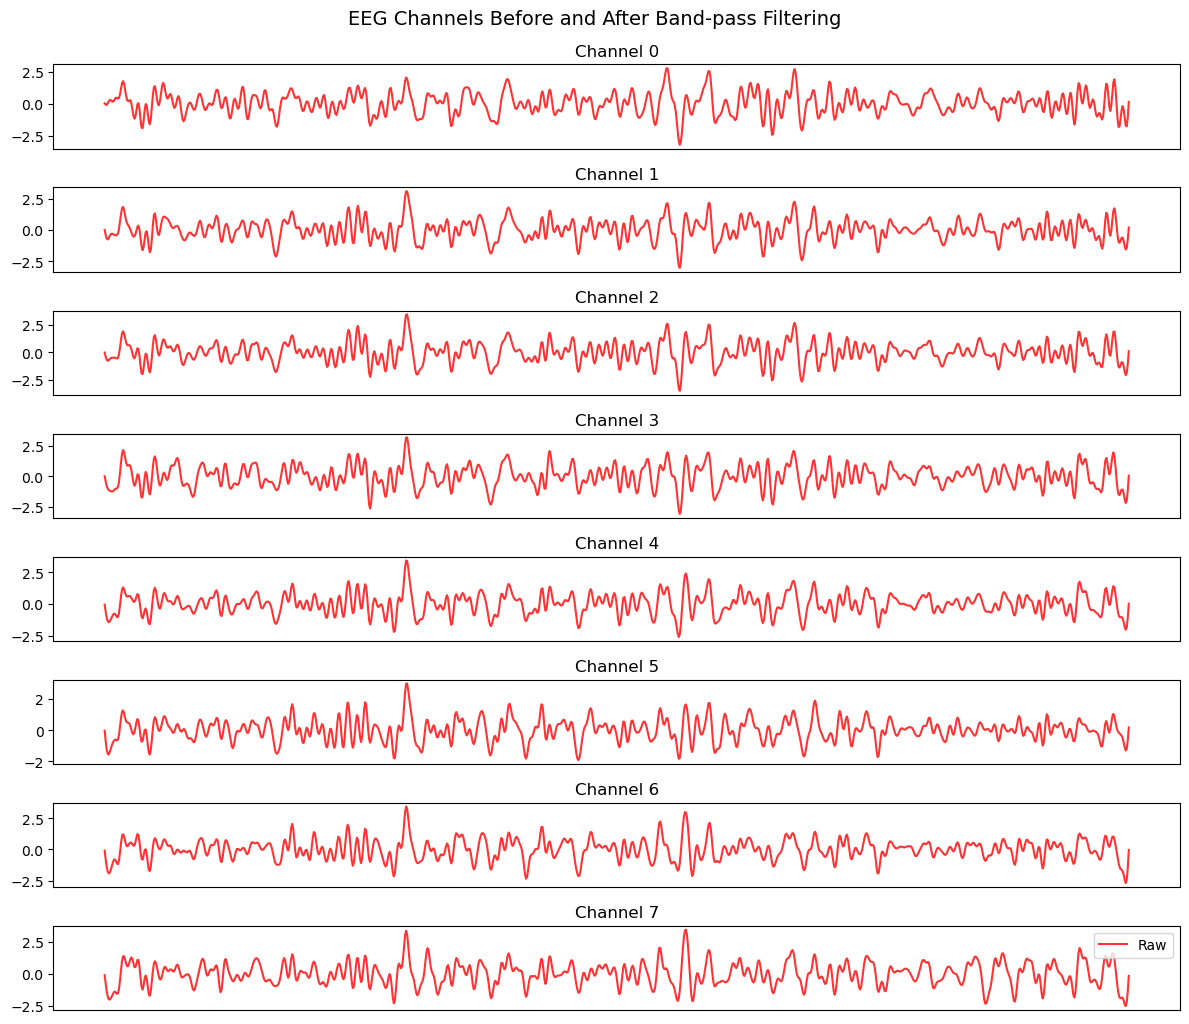

In [16]:
plt.figure(figsize=(12, 10))
example_raw = eeg_train_trials[0]
example_filtered = filtered_train[0]
for i in range(example_raw.shape[1]):
    plt.subplot(8, 1, i + 1)
    # plt.plot(example_raw[:4000, i], color='gray', alpha=0.5, label='Raw')
    plt.plot(example_filtered[:4000, i], color='red', alpha=0.8, label='Filtered')
    plt.title(f"Channel {i}")
    plt.xticks([])
    plt.tight_layout()

plt.legend(['Raw', 'Filtered'], loc='upper right')
plt.suptitle("EEG Channels Before and After Band-pass Filtering", fontsize=14, y=1.02)
plt.show()



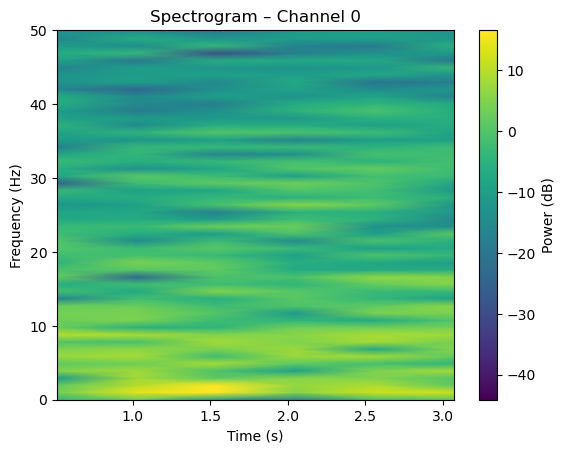

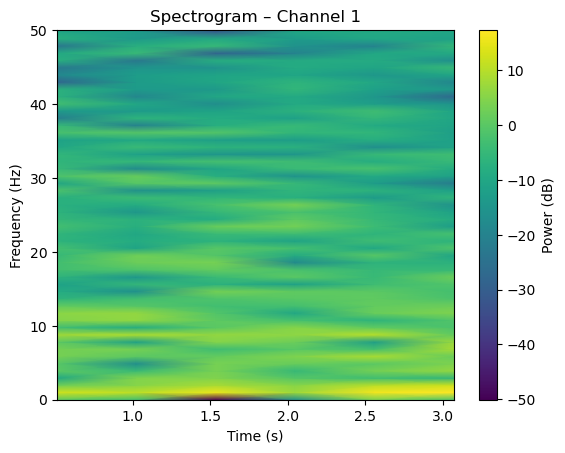

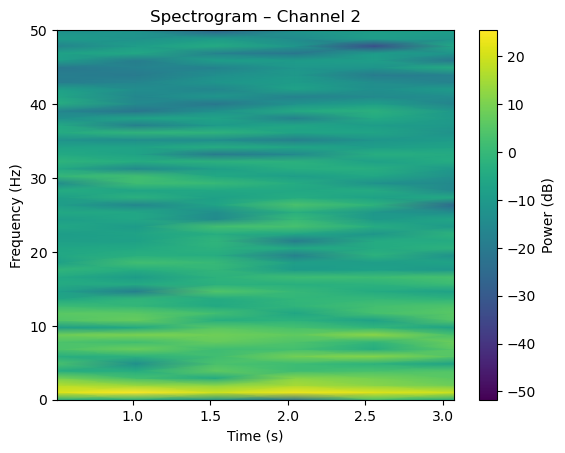

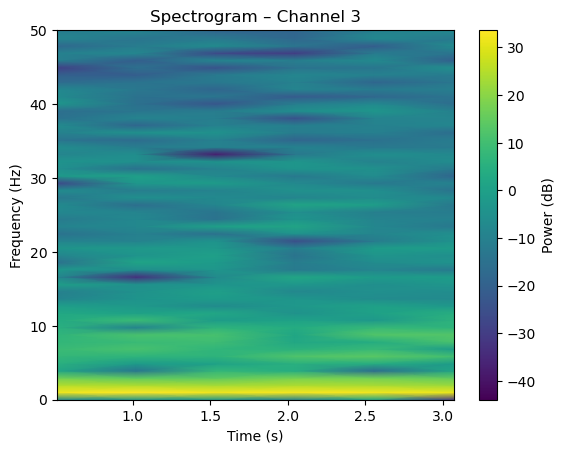

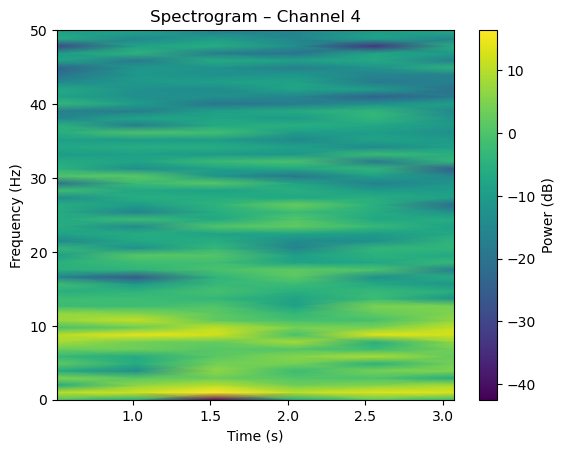

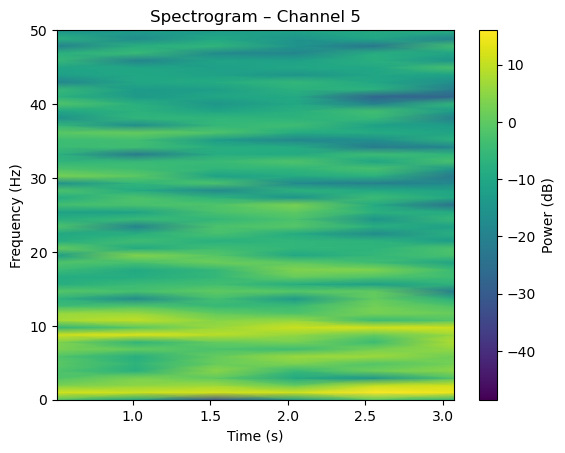

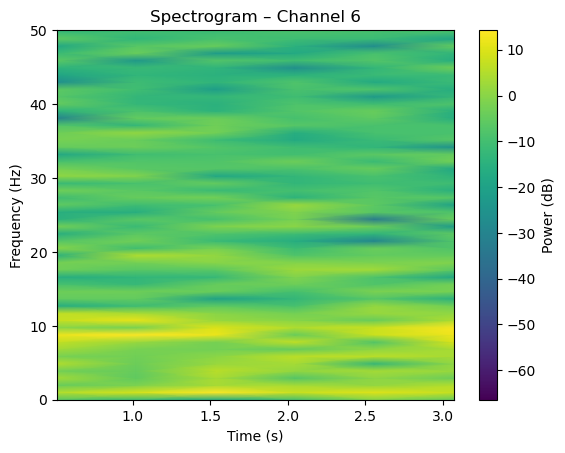

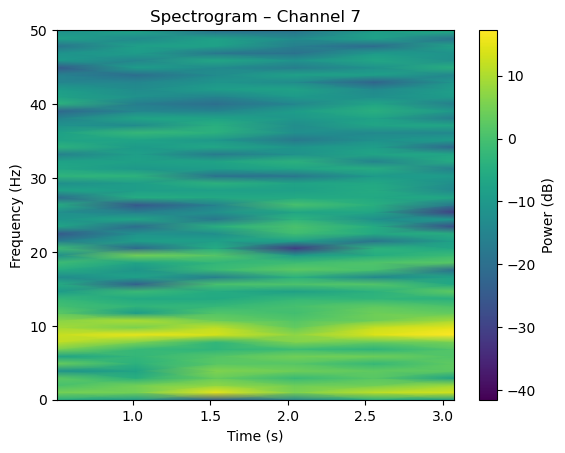

In [17]:
from scipy.signal import spectrogram

ch = 0
for i in range(readings.shape[1]):
    f, t, Sxx = spectrogram(readings[4000:5000, i], fs, nperseg=256, noverlap=128)
    plt.pcolormesh(t, f, 10*np.log10(Sxx), shading='gouraud')
    plt.title(f"Spectrogram – Channel {i}")
    plt.ylabel('Frequency (Hz)')
    plt.xlabel('Time (s)')
    plt.ylim(0, 50)
    plt.colorbar(label='Power (dB)')
    plt.show()




filtered_readings shape: (200000, 8)
Creating RawArray with float64 data, n_channels=8, n_times=200000
    Range : 0 ... 199999 =      0.000 ...   799.996 secs
Ready.
Fitting ICA...
Fitting ICA to data using 8 channels (please be patient, this may take a while)


C:\Users\Shivansh Sharma\AppData\Local\Temp\ipykernel_14488\2568199852.py:19: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw_mne)


Selecting by number: 8 components
Fitting ICA took 1.8s.


C:\Users\Shivansh Sharma\AppData\Local\Temp\ipykernel_14488\2568199852.py:19: RuntimeWarning: Using n_components=8 (resulting in n_components_=8) may lead to an unstable mixing matrix estimation because the ratio between the largest (8) and smallest (1.2e-06) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 5
  ica.fit(raw_mne)


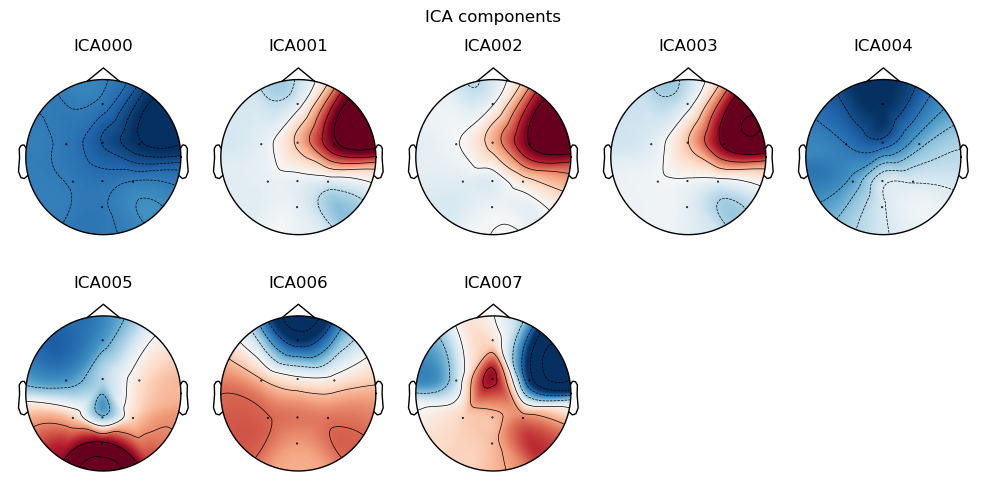

Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Zeroing out 1 ICA component
    Projecting back using 8 PCA components
filtered_clean shape: (200000, 8)


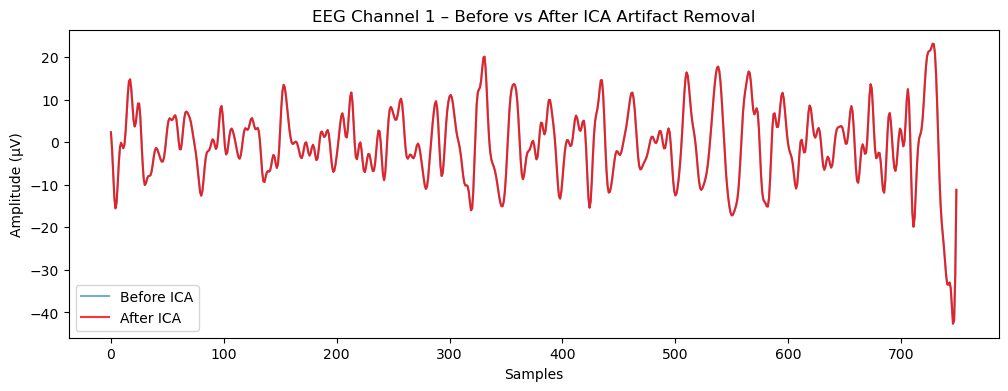

In [18]:
import mne


fs = 250
# Use realistic EEG channel names if possible
ch_names = ['Fz','C3','Cz','C4','P3','Pz','P4','Oz']
ch_types = ['eeg'] * 8
info = mne.create_info(ch_names=ch_names, sfreq=fs, ch_types=ch_types)

print("filtered_readings shape:", filtered_readings.shape)
raw_mne = mne.io.RawArray(filtered_readings.T, info)

# ✅ Add montage to provide electrode positions
montage = mne.channels.make_standard_montage('standard_1020')
raw_mne.set_montage(montage)
# --- Run ICA ---
ica = mne.preprocessing.ICA(n_components=8, random_state=42, max_iter=500)
print("Fitting ICA...")
ica.fit(raw_mne)

# --- Visualize components safely ---
ica.plot_components()  # now works, shows scalp maps
# OR if you only want time-series of activations:
# ica.plot_sources(raw_mne)

# --- Optionally exclude components ---
ica.exclude = [0]  # change after visual inspection
raw_clean = ica.apply(raw_mne)

filtered_clean = raw_clean.get_data().T
print("filtered_clean shape:", filtered_clean.shape)

# --- Quick comparison ---
plt.figure(figsize=(12, 4))
plt.plot(filtered_readings[4250:5000, 0], label='Before ICA', alpha=0.6)
plt.plot(filtered_clean[4250:5000, 0], label='After ICA', color='red', alpha=0.8)
plt.title('EEG Channel 1 – Before vs After ICA Artifact Removal')
plt.xlabel('Samples')
plt.ylabel('Amplitude (µV)')
plt.legend()
plt.show()

In [19]:
# %%
# ICA ARTIFACT REMOVAL (DISABLED FOR ONLINE TRAINING - TOO SLOW)
# Uncomment the code below if you want to use ICA offline
# ICA fitted on TRAIN only to avoid leakage

# import mne
# 
# ch_names = ['Fz','C3','Cz','C4','P3','Pz','P4','Oz']
# ch_types = ['eeg'] * len(ch_names)
# info = mne.create_info(ch_names=ch_names, sfreq=fs, ch_types=ch_types)
# montage = mne.channels.make_standard_montage('standard_1020')
# 
# 
# def trials_to_raw(trial_block):
#     data = trial_block.reshape(-1, trial_block.shape[2]).T
#     raw = mne.io.RawArray(data, info.copy())
#     raw.set_montage(montage)
#     return raw
# 
# 
# train_raw = trials_to_raw(filtered_train)
# ica = mne.preprocessing.ICA(n_components=len(ch_names), random_state=42, max_iter=500)
# print("Fitting ICA on TRAIN trials only...")
# ica.fit(train_raw)
# 
# train_raw_clean = ica.apply(train_raw.copy())
# filtered_train_clean = train_raw_clean.get_data().T.reshape(filtered_train.shape)
# 
# test_raw = trials_to_raw(filtered_test)
# test_raw_clean = ica.apply(test_raw.copy())
# filtered_test_clean = test_raw_clean.get_data().T.reshape(filtered_test.shape)
# 
# print("filtered_train_clean shape:", filtered_train_clean.shape)
# print("filtered_test_clean shape:", filtered_test_clean.shape)
# 
# plt.figure(figsize=(12, 4))
# plt.plot(filtered_train[0, :750, 0], label='Before ICA', alpha=0.6)
# plt.plot(filtered_train_clean[0, :750, 0], label='After ICA', color='red', alpha=0.8)
# plt.title('EEG Channel 0 – Before vs After ICA Artifact Removal')
# plt.xlabel('Samples')
# plt.ylabel('Amplitude (µV)')
# plt.legend()
# plt.show()

# SKIP ICA: Use bandpass-filtered data directly
print("Skipping ICA (disabled for online training)")
print("Using bandpass-filtered data directly...")
filtered_train_clean = filtered_train
filtered_test_clean = filtered_test

print("filtered_train_clean shape:", filtered_train_clean.shape)
print("filtered_test_clean shape:", filtered_test_clean.shape)
print("(Note: These are the same as filtered_train/test since ICA is disabled)")



Skipping ICA (disabled for online training)
Using bandpass-filtered data directly...
filtered_train_clean shape: (164, 1000, 8)
filtered_test_clean shape: (36, 1000, 8)
(Note: These are the same as filtered_train/test since ICA is disabled)


In [20]:
# %%
# Standardize channels using TRAIN statistics only
# NOTE: Skip this step when using automatic detection (data_curation.py uses z-score normalization instead)

if TRIAL_DETECTION_METHOD == 'automatic':
    print("Skipping StandardScaler normalization (using z-score normalization from data_curation.py instead)")
    # Already normalized in Cell 12, so just pass through
    eeg_norm_train = filtered_train_clean
    eeg_norm_test = filtered_test_clean
else:
    print("Applying StandardScaler normalization...")
    from sklearn.preprocessing import StandardScaler
    
    scaler = StandardScaler()
    train_flat = filtered_train_clean.reshape(-1, filtered_train_clean.shape[2])
    test_flat = filtered_test_clean.reshape(-1, filtered_test_clean.shape[2])
    
    scaler.fit(train_flat)
    train_norm = scaler.transform(train_flat).reshape(filtered_train_clean.shape)
    test_norm = scaler.transform(test_flat).reshape(filtered_test_clean.shape)
    
    eeg_norm_train = train_norm
    eeg_norm_test = test_norm

print("train_norm shape:", eeg_norm_train.shape)
print("test_norm shape:", eeg_norm_test.shape)



Applying StandardScaler normalization...
train_norm shape: (164, 1000, 8)
test_norm shape: (36, 1000, 8)


In [21]:
# %%
# Encode labels to 0..N-1
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(np.concatenate([lbl_train_trials, lbl_test_trials]))

lbl_train = label_encoder.transform(lbl_train_trials)
lbl_test = label_encoder.transform(lbl_test_trials)

print("Unique encoded labels (train):", np.unique(lbl_train, return_counts=True))
print("Unique encoded labels (test) :", np.unique(lbl_test, return_counts=True))



Unique encoded labels (train): (array([0, 1]), array([82, 82]))
Unique encoded labels (test) : (array([0, 1]), array([18, 18]))


In [22]:

scaler = StandardScaler()
eeg_norm = scaler.fit_transform(filtered_readings)  # shape: (n_samples, 8)

print("eeg_norm shape:", eeg_norm)

eeg_norm shape: [[-0.00629238  0.02546597  0.00586282 ...  0.00500713  0.00829697
   0.02293215]
 [ 0.18593293  0.14046264  0.04961208 ... -0.05515912 -0.06608245
   0.06542712]
 [ 0.17699217  0.14868777  0.06097847 ... -0.10630657 -0.10903665
   0.13546847]
 ...
 [-0.52762292 -0.5082395  -0.09980255 ... -0.01738011  0.02031428
   0.26423248]
 [-0.3228349  -0.31521766 -0.06099798 ... -0.01800642  0.02855015
   0.20084369]
 [-0.14920549 -0.15826918 -0.02686204 ... -0.04337031  0.04682608
   0.18348118]]


In [23]:
# label_encoder = LabelEncoder()
# labels_encoded = label_encoder.fit_transform(labels)
# print("labels_encoded shape:", labels_encoded)
# print(labels)

# Verify labels are numeric
print("Unique labels before encoding:", np.unique(labels))
print("Labels dtype:", labels.dtype)

# Since labels are already 1, 2, 3 format, just convert to int
labels_encoded = labels.astype(int)
print("labels_encoded shape:", labels_encoded.shape)
print("Unique encoded labels:", np.unique(labels_encoded))
print("Label distribution:", np.unique(labels_encoded, return_counts=True))

Unique labels before encoding: [1 2]
Labels dtype: int64
labels_encoded shape: (200000,)
Unique encoded labels: [1 2]
Label distribution: (array([1, 2]), array([100000, 100000]))


In [24]:
# # Split indices for train/test
# train_idx_filtered = np.where(split == 'train')[0]
# test_idx_filtered  = np.where(split == 'test')[0]

# eeg_train_data = eeg_norm[train_idx_filtered]
# lbl_train = labels_encoded[train_idx_filtered]

# eeg_test_data = eeg_norm[test_idx_filtered]
# lbl_test = labels_encoded[test_idx_filtered]

# print("Train samples:", eeg_train_data.shape[0])
# print("Test samples :", eeg_test_data.shape[0])
# print("Train label distribution:", np.unique(lbl_train, return_counts=True))
# print("Test label distribution:", np.unique(lbl_test, return_counts=True))

# print("Train samples:", eeg_train.shape[0])
# print("Test samples :", eeg_test.shape[0])

In [25]:
# -------------------------------
def create_epochs(eeg_array, labels_array, stride, window, amp_thresh=150):
    X, y = [], []
    for start in range(0, len(eeg_array) - window, stride):
        end = start + window
        epoch = eeg_array[start:end, :]
        epoch_labels = labels_array[start:end]
        # majority label in the window
        majority = np.bincount(epoch_labels).argmax()
        purity = np.mean(epoch_labels == majority)
        if purity >= 0.9 and np.max(np.abs(epoch)) < amp_thresh:
            X.append(epoch)
            y.append(majority)
    return np.array(X), np.array(y)

In [26]:
# %%
# Override with trial-aware epoching

def create_epochs(trial_block, label_block, stride, window, amp_thresh=150):
    """Slide windows within each trial so labels stay aligned."""
    X, y = [], []
    for trial, label in zip(trial_block, label_block):
        for start in range(0, trial.shape[0] - window + 1, stride):
            epoch = trial[start:start + window, :]
            if np.max(np.abs(epoch)) < amp_thresh:
                X.append(epoch)
                y.append(label)
    return np.array(X), np.array(y)



In [27]:
# train_idx = np.where(split == 'train')[0]
# test_idx  = np.where(split == 'test')[0]

# eeg_train, lbl_train = eeg_norm[train_idx], labels_encoded[train_idx]
# eeg_test,  lbl_test  = eeg_norm[test_idx],  labels_encoded[test_idx]
# print("Train samples:", eeg_train.shape[0])
# print("Test samples :", eeg_test.shape[0])

In [ ]:
# window_sec = 1
# window_size = fs * window_sec          # 250 samples per 1 s
# train_stride = window_size // 2        # 50 % overlap
# test_stride  = window_size             # no overlap
# amp_thresh = 150   

# # X_train, y_train = create_epochs(eeg_train, lbl_train,
# #                                  stride=train_stride, window=window_size)
# # X_test, y_test = create_epochs(eeg_test, lbl_test,
# #                                stride=test_stride, window=window_size)

# X_train, y_train = create_epochs(eeg_train_data, lbl_train,
#                                  stride=train_stride, window=window_size)
# X_test, y_test = create_epochs(eeg_test_data, lbl_test,
#                                stride=test_stride, window=window_size)

# print("Train epochs:", X_train.shape, "Test epochs:", X_test.shape)

window_sec = 2
window_size = fs * window_sec          # 250 samples per 1 s
# train_stride = window_size // 2        # 50% overlap
train_stride = int(window_size * 0.3)  # 70% overlap
test_stride  = window_size             # no overlap
amp_thresh = 150   

X_train, y_train = create_epochs(eeg_norm_train, lbl_train,
                                 stride=train_stride, window=window_size)
X_test, y_test = create_epochs(eeg_norm_test, lbl_test,
                               stride=test_stride, window=window_size)

print("Train epochs:", X_train.shape, "Test epochs:", X_test.shape)
print("Train epoch labels:", np.unique(y_train, return_counts=True))
print("Test epoch labels:", np.unique(y_test, return_counts=True))

Train epochs: (1803, 250, 8) Test epochs: (144, 250, 8)
Train epoch labels: (array([0, 1]), array([902, 901]))
Test epoch labels: (array([0, 1]), array([72, 72]))


In [29]:
def normalize_epoch(epoch):
    mean = epoch.mean(axis=0, keepdims=True)
    std = epoch.std(axis=0, keepdims=True) + 1e-8
    return (epoch - mean) / std

X_train = np.array([normalize_epoch(e) for e in X_train])
X_test  = np.array([normalize_epoch(e) for e in X_test])

# --- Reshape for EEGNet ---
# EEGNet expects (N, 1, C, T) format for Conv2d
# Current shape: (N, T, C) -> transpose to (N, C, T) -> add channel dim -> (N, 1, C, T)
X_train_eegnet = np.transpose(X_train, (0, 2, 1))  # (N, C, T)
X_test_eegnet  = np.transpose(X_test,  (0, 2, 1))  # (N, C, T)

# Add channel dimension for EEGNet: (N, C, T) -> (N, 1, C, T)
X_train_eegnet = np.expand_dims(X_train_eegnet, axis=1)  # (N, 1, C, T)
X_test_eegnet = np.expand_dims(X_test_eegnet, axis=1)   # (N, 1, C, T)

print("EEGNet train shape:", X_train_eegnet.shape)
print("EEGNet test shape:", X_test_eegnet.shape)
print("Note: EEGNet can also accept (N, C, T) format - the model handles both")


EEGNet train shape: (1803, 1, 8, 250)
EEGNet test shape: (144, 1, 8, 250)
Note: EEGNet can also accept (N, C, T) format - the model handles both


In [30]:
np.save("X_train_eegnet.npy", X_train_eegnet)
np.save("y_train_eegnet.npy", y_train)
np.save("X_test_eegnet.npy",  X_test_eegnet)
np.save("y_test_eegnet.npy",  y_test)

print("Data saved successfully!")
print("Files saved:")
print("  - X_train_eegnet.npy")
print("  - y_train_eegnet.npy")
print("  - X_test_eegnet.npy")
print("  - y_test_eegnet.npy")


Data saved successfully!
Files saved:
  - X_train_eegnet.npy
  - y_train_eegnet.npy
  - X_test_eegnet.npy
  - y_test_eegnet.npy
